### Local explainability with SHAP

### Global Vs. Local explainability
| Global explainability | Local explainability|
| ----------------| -------------|
| Overall model behavior | EXplains prediction for specific data point|
|Doesn't explain individual instances | Crucial for sensitive applications |

In [1]:
import pandas as pd
heart = pd.read_csv("heart.csv")
heart.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [3]:
X = heart.drop(columns=["target"], axis=0)
y = heart['target']

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [7]:
### Local explainability with SHAP
import shap
explainer = shap.KernelExplainer(knn.predict_proba, shap.kmeans(X, 10))

test_instance = X.iloc[0, :]

shap_values = explainer.shap_values(test_instance)

print(shap_values.shape)

(13, 2)


### SHAP waterfall plots
- Shows how features increase or decrease model's prediction

Creating waterfall plots

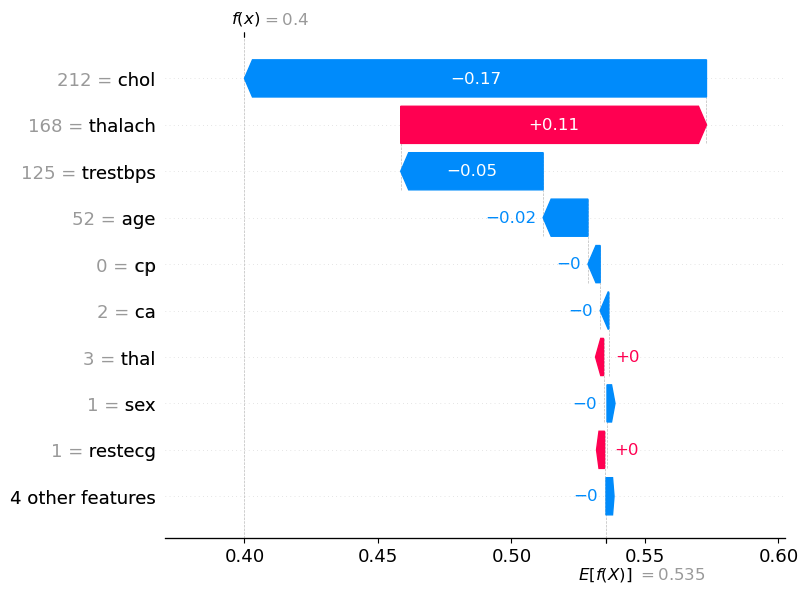

In [8]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[:,1],
        base_values=explainer.expected_value[1],
        data=test_instance,
        feature_names=X.columns

    )
)

In [ ]:
import shap

# Create the SHAP explainer
explainer = shap.KernelExplainer(model.predict_proba, shap.kmeans(X, 10))

# Compute SHAP values for the first instance in X
shap_values =explainer.shap_values( X.iloc[0, :])

print(shap_values)

In [ ]:
import shap

# Create the SHAP explainer
explainer = shap.KernelExplainer(model.predict_proba, shap.kmeans(X, 10))

# Compute SHAP values for the first instance in the test dataset
shap_values = explainer.shap_values(X.iloc[0,:])

# Plot the SHAP values using a waterfall plot
shap.waterfall_plot(shap.Explanation(values=shap_values[:, 1], 
                    base_values=explainer.expected_value[1], 
                    data=X.iloc[0, :], 
                    feature_names=X.columns))

### Local explainability with LIME
- LIME -> Local Interpretable Model-Agnostic Explanations
- Explains predictions of complex models
- Works on inidividual instances
- Agnostic to model type

### Lime explainers
- Tailored to different kinds of data
- Generates perturbations around a sample
- Sees effect on model's output
- Constructs simpler model for explanation

In [9]:
admission = pd.read_csv("admission_data.csv")
admission.head(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Accept
0,337,118,4,4.5,4.5,9.65,0.92,1
1,324,107,4,4.0,4.5,8.87,0.76,1
2,316,104,3,3.0,3.5,8.00,0.72,1
3,322,110,3,3.5,2.5,8.67,0.80,1
4,314,103,2,2.0,3.0,8.21,0.65,0
5,330,115,5,4.5,3.0,9.34,0.90,1
6,321,109,3,3.0,4.0,8.20,0.75,1
7,308,101,2,3.0,4.0,7.90,0.68,0
8,302,102,1,2.0,1.5,8.00,0.50,0
9,323,108,3,3.5,3.0,8.60,0.45,0


In [13]:
admission = admission.dropna()
X = admission.drop(columns=["Accept"], axis=0)
y = admission["Accept"]

In [14]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, stratify=y)

regressor = LinearRegression()
regressor.fit(X_train, y_train)


LinearRegression()

### CLassification part

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize the classification model
classifier = RandomForestClassifier(random_state=42)

# Fit the model
classifier.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

### Creating tabular explainer
- Regression

In [17]:
pip install lime

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283917 sha256=b6636ed99788cb481a3ebc0b532898da45320d18d7364289b8792e1d82d654d1
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [20]:
from lime.lime_tabular import LimeTabularExplainer
instance = X.iloc[1, :]
# Make sure to use "Lime" instead of "Line"
explainer_reg = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    mode="regression" # Note: use "classification" here if you are predicting the binary "Accept" column
)

explaination_reg = explainer_reg.explain_instance(
    instance.values,
    regressor.predict
)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


- CLasification

In [21]:
from lime.lime_tabular import LimeTabularExplainer
instance = X.iloc[1, :]

explainer_class = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    mode='classification'
)

explaination_class = explainer_class.explain_instance(
    instance.values,
    classifier.predict_proba
)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Visualization explanation
- Regression

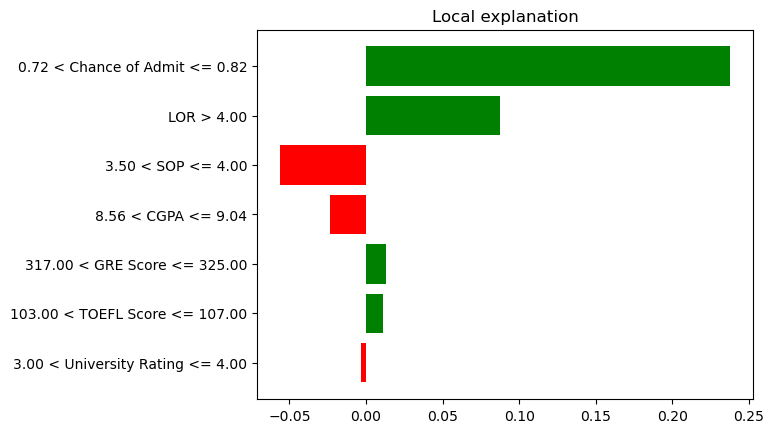

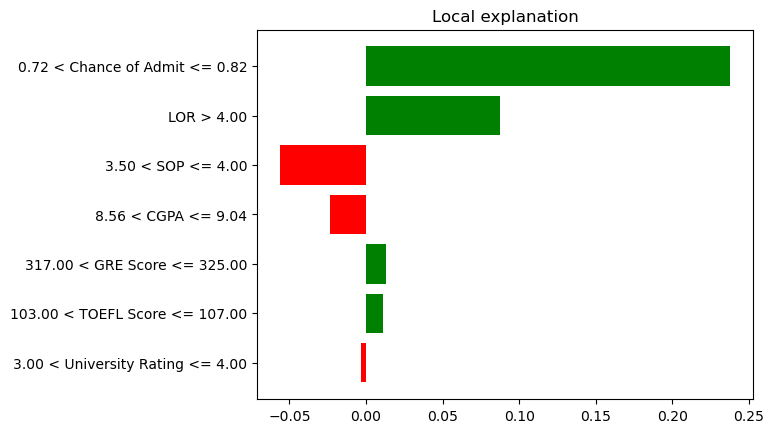

In [23]:
explaination_reg.as_pyplot_figure()

- Classification

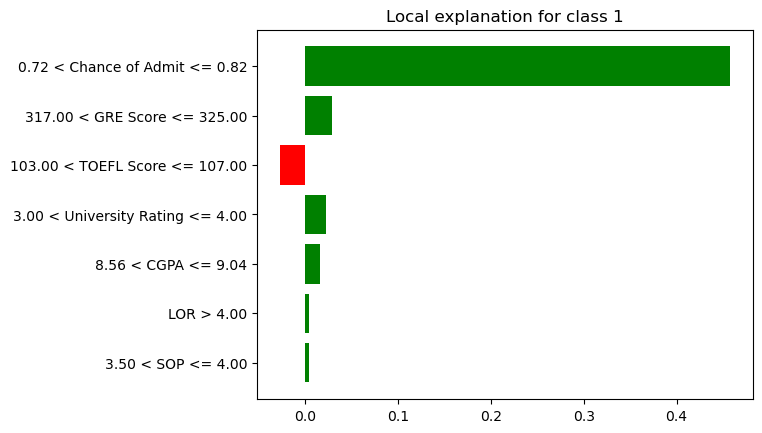

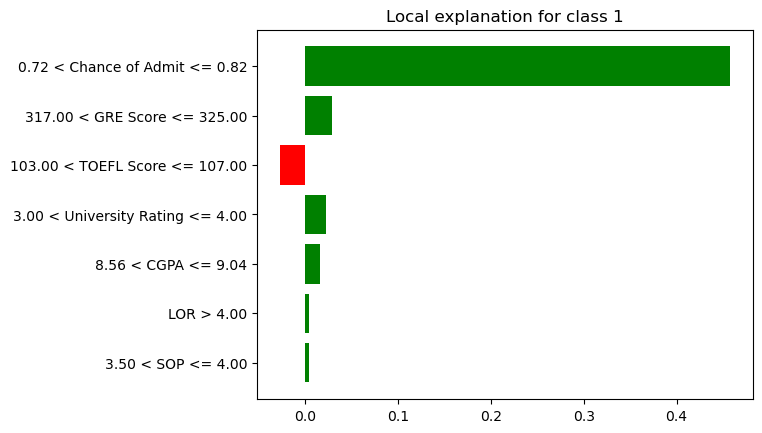

In [25]:
explaination_class.as_pyplot_figure()

### Exercise:
- Interpreting regressors locally

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

sample_data_point = X.iloc[2, :]

# Create the explainer
explainer = LimeTabularExplainer(
    X.values,
    feature_names = X.columns,
    mode='regression'
)

# Generate the explanation
exp = explainer.explain_instance(
    sample_data_point.values,
    model.predict
)
# Display the explanation
exp.as_pyplot_figure()
plt.show()

- Interpreting classifiers locally

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

sample_data_point = X.iloc[2, :]

# Create the explainer
explainer = LimeTabularExplainer(
    X.values,
    feature_names = X.columns,
    mode = 'classification'
)

# Generate the explanation
exp = explainer.explain_instance(
    sample_data_point.values,
    model.predict_proba
)

# Display the explanation
exp.as_pyplot_figure()
plt.show()

Text and Image explainability with LIME
- Text-based models
    - Process and interpret written language
    - Example: Sentiment analysis
    - Black box models
    - `LimeTextExplainer` explains such models
    - Finds how each word impacts prediction
        - Find how each world impacts predictions
    


Lime Text explainer

In [ ]:
from lime.lime_text import LimeTabularExplainer

text_instance = "This product has great features but a poor designs."

def model_predict(instance):
    return class_probabilities


explainer = LineTextExplainer()
exp = explainer.explain_instance(
    text_instance,
    model_predict
)

exp.as_pyplot_figure()

### Image-based models
- Highly complex
- Interpret visual data
- Example: Food Classifiation
- `LimeImageExplainer` explains such models
    - FInds which parts of image impact predictions


#### LIME image explainer

In [ ]:
from lime.lime_image import LimeImageExplainer

explainer = LimeImageExplainer()
explanation = explainer.explain_instance(
    image,
    model_predict,
    num_samples=50
)

temp, _ = explanation.get_image_and_mask(

    explanation.to_labels[0],
    hide_rest=True
)
plt.imshow(temp)

NameError: name 'image' is not defined

Explaining sentiment analysis predictions

In [ ]:
from lime.lime_text import LimeTextExplainer

text_instance = "Amazing battery life and the camera quality is perfect! I highly recommend this smartphone."

# Create a LIME text explainer
explainer = LimeTextExplainer()

# Generate the explanation
exp = explainer.explain_instance(
    text_instance,
    model_predict
)
# Display the explanation
exp.as_pyplot_figure()
plt.show()

In [ ]:
from lime import lime_image
np.random.seed(10)

# Create a LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate the explanation
explanation = explainer.explain_instance(image, model_predict, hide_color=0, num_samples=50)

# Display the explanation
temp, _ = explanation.get_image_and_mask(explanation.top_labels[0], hide_rest=True)
plt.title('LIME Explanation')
plt.axis('off')
plt.show()